# Neural Ratio Estimation with PyMC Integration

This notebook demonstrates how to:

1. Train a BayesFlow `RatioApproximator` on a **2-parameter normal model** ($\mu$, $\sigma$)
2. Extract a **pure JAX callable** for the single-trial log-ratio
3. Investigate the extracted function visually
4. Wrap it in **PyTensor Ops** with full VJP gradient support (HSSM-style)
5. Build a proper **`pm.Distribution`** whose `logp` accepts vector parameters
6. Run **NUTS sampling** in PyMC (scalar-parameter case)
7. Demonstrate a **regression model** where $\mu$ varies per trial via covariates

## Part 1: Train the Ratio Estimator

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as sp_norm

import jax
import jax.numpy as jnp
from jax import jit, vjp, vmap
from jax.tree_util import Partial

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
from pytensor.link.jax.dispatch import jax_funcify

INFO:2026-02-16 19:14:19,201:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO

### Generative Model

We use a 2-parameter normal model:
$$x \mid \mu, \sigma \sim \mathcal{N}(\mu, \sigma^2)$$

with priors $\mu \sim \text{Uniform}(-5, 5)$ and $\sigma \sim \text{Uniform}(0.5, 3.0)$.

The ratio estimator learns the **single-observation** log-ratio
$\log r(\mu, \sigma, x) = \log \frac{p(x \mid \mu, \sigma)}{p(x)}$,
which factorizes across i.i.d. observations:
$\log r(\mu, \sigma, x_{1:n}) = \sum_{i=1}^{n} \log r(\mu, \sigma, x_i)$.

In [2]:
def prior():
    mu = np.random.uniform(-5, 5)
    sigma = np.random.uniform(0.5, 3.0)
    return {"mu": mu, "sigma": sigma}

def likelihood(mu, sigma):
    return {"x": mu + sigma * np.random.standard_normal()}

In [3]:
simulator = bf.make_simulator([prior, likelihood])

# Quick test
test_sims = simulator.sample(3)
for k, v in test_sims.items():
    print(k, v.shape)

mu (3, 1)
sigma (3, 1)
x (3, 1)


### Build Adapter & Train

In [4]:
adapter = bf.approximators.RatioApproximator.build_adapter(
    inference_variables=["mu", "sigma"],
    inference_conditions=["x"]
)

ratio_approximator = bf.approximators.RatioApproximator(
    adapter=adapter,
    classifier_network=bf.networks.MLP(widths=[128, 128, 128]),
    standardize=None,  # Keep things simple; no standardization for now
)

In [5]:
ratio_approximator.compile(optimizer="adam")

history = ratio_approximator.fit(
    simulator=simulator,
    epochs=100,
    num_batches=200,
    batch_size=64,
)

INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 12 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5157
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2361
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2108
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2010
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1937
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1858
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1854
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1904
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1822
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1832
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1817
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1727
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1684
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1677
Epoch 15/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1

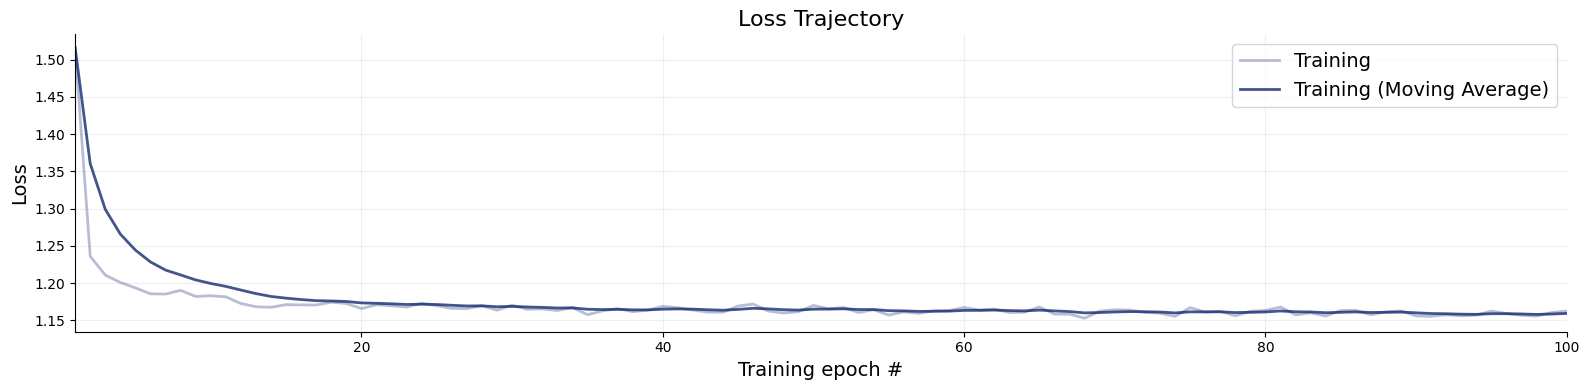

In [6]:
f = bf.diagnostics.plots.loss(history)

### Sanity Check: Positive vs. Contrastive Log-Ratios

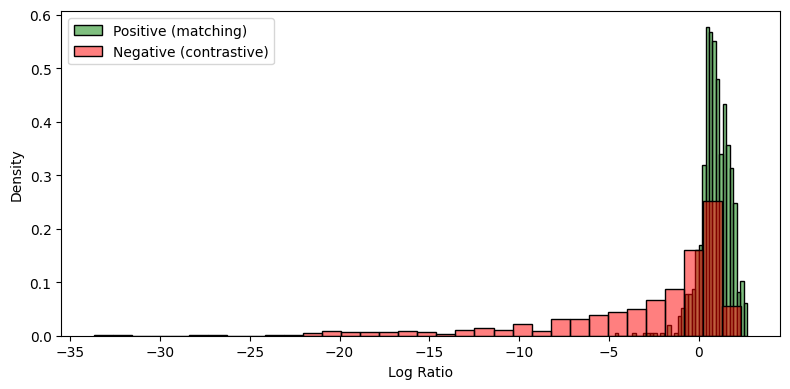

In [7]:
sims = simulator.sample(1000)
contrastive_sims = {
    "mu": sims["mu"][::-1],
    "sigma": sims["sigma"][::-1],
    "x": sims["x"]
}

log_ratio_positive = keras.ops.convert_to_numpy(ratio_approximator.log_ratio(sims))
log_ratio_negative = keras.ops.convert_to_numpy(ratio_approximator.log_ratio(contrastive_sims))

f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(log_ratio_positive, stat="density", ax=ax, label="Positive (matching)", color="green", alpha=0.5)
sns.histplot(log_ratio_negative, stat="density", ax=ax, label="Negative (contrastive)", color="red", alpha=0.5)
ax.set_xlabel("Log Ratio")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 2: Extract a JAX-native Single-Trial Function

The key insight: since BayesFlow uses Keras 3 with the JAX backend, we can call the
classifier network **directly** with JAX arrays, bypassing the dict-based adapter.

We define `make_jax_log_ratio_fn` which returns a pure JAX callable with signature:
```
f(x_i, mu, sigma) -> scalar log_ratio
```
This is the **single-trial** function that will be `vmap`-ed and wrapped in PyTensor Ops.

In [8]:
def make_jax_log_ratio_fn(ratio_approximator):
    """Extract a pure JAX single-trial log-ratio callable from a trained RatioApproximator.
    
    Returns a function with signature: f(x_i, mu, sigma) -> scalar log_ratio
    where x_i, mu, sigma are all JAX scalars.
    """
    classifier = ratio_approximator.classifier_network
    projector = ratio_approximator.projector
    
    # Capture standardization layers if they exist
    std_layers = ratio_approximator.standardize_layers if hasattr(ratio_approximator, 'standardize_layers') else {}
    std_keys = ratio_approximator.standardize if hasattr(ratio_approximator, 'standardize') else []
    if std_layers is None:
        std_layers = {}
    if std_keys is None:
        std_keys = []
    
    def single_trial_log_ratio(x_i, *params):
        """Compute log-ratio for a single trial.
        
        Parameters
        ----------
        x_i : scalar observation
        *params : (mu, sigma) as scalars
        
        Returns
        -------
        scalar log_ratio
        """
        # Construct inference_variables = [mu, sigma] and inference_conditions = [x_i]
        inf_vars = jnp.array(list(params))     # shape (n_params,)
        inf_conds = jnp.atleast_1d(x_i)        # shape (1,)
        
        # Apply standardization if configured
        if "inference_variables" in std_keys and "inference_variables" in std_layers:
            inf_vars = std_layers["inference_variables"](inf_vars[None, :], training=False)[0]
        if "inference_conditions" in std_keys and "inference_conditions" in std_layers:
            inf_conds = std_layers["inference_conditions"](inf_conds[None, :], training=False)[0]
        
        # Concatenate: [mu, sigma, x_i] -- same order as the adapter produces
        classifier_input = jnp.concatenate([inf_vars, inf_conds])
        
        # Add batch dim, run network, remove batch dim
        hidden = classifier(classifier_input[None, :], training=False)
        logits = projector(hidden, training=False)
        return jnp.squeeze(logits)
    
    return single_trial_log_ratio

single_trial_fn = make_jax_log_ratio_fn(ratio_approximator)

# Quick test: evaluate at a single point
test_val = single_trial_fn(jnp.array(1.0), jnp.array(0.0), jnp.array(1.0))
print(f"Single trial log-ratio at (x=1, mu=0, sigma=1): {test_val:.4f}")

Single trial log-ratio at (x=1, mu=0, sigma=1): 1.0293


---
## Part 2b: Investigate the Single-Trial Log-Ratio

Before wiring the extracted function into PyTensor, we validate that:
1. The extracted JAX function matches the original `ratio_approximator.log_ratio()` output
2. The log-ratio landscape is sensible when plotted against the analytic log-likelihood

### Consistency Check: Extracted vs. Original

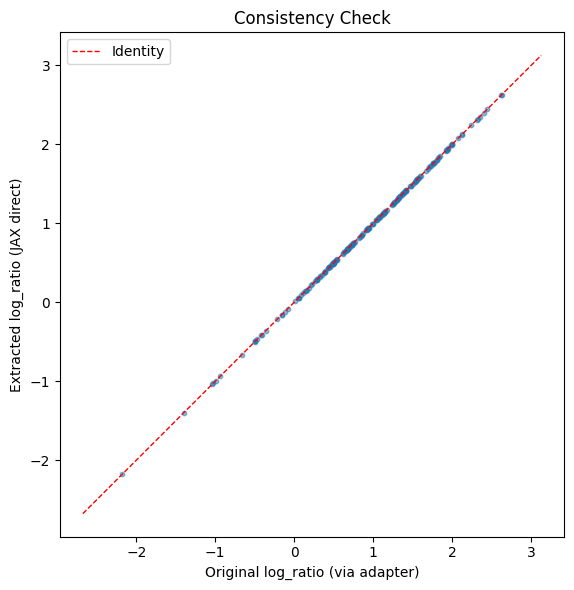

Max absolute difference: 7.15e-07


In [9]:
# Generate test data
n_test = 200
test_data = simulator.sample(n_test)

# Original path: through the adapter
original_lr = keras.ops.convert_to_numpy(ratio_approximator.log_ratio(test_data)).flatten()

# Extracted path: call the JAX function directly via vmap
vmap_fn = jax.vmap(single_trial_fn, in_axes=(0, 0, 0))
extracted_lr = np.asarray(vmap_fn(
    jnp.array(test_data["x"].flatten()),
    jnp.array(test_data["mu"].flatten()),
    jnp.array(test_data["sigma"].flatten()),
)).flatten()

f, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(original_lr, extracted_lr, alpha=0.5, s=10)
lims = [min(original_lr.min(), extracted_lr.min()) - 0.5, max(original_lr.max(), extracted_lr.max()) + 0.5]
ax.plot(lims, lims, 'r--', lw=1, label='Identity')
ax.set_xlabel("Original log_ratio (via adapter)")
ax.set_ylabel("Extracted log_ratio (JAX direct)")
ax.set_title("Consistency Check")
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(original_lr - extracted_lr))
print(f"Max absolute difference: {max_diff:.2e}")

### Log-Ratio Landscape: 2D Heatmap

We fix a single observation $x_{obs} = 2.0$ and plot the log-ratio as a function of
$(\mu, \sigma)$. We also overlay the analytic log-likelihood $\log \mathcal{N}(x_{obs} \mid \mu, \sigma)$.
The two should match up to a constant offset (the log evidence).

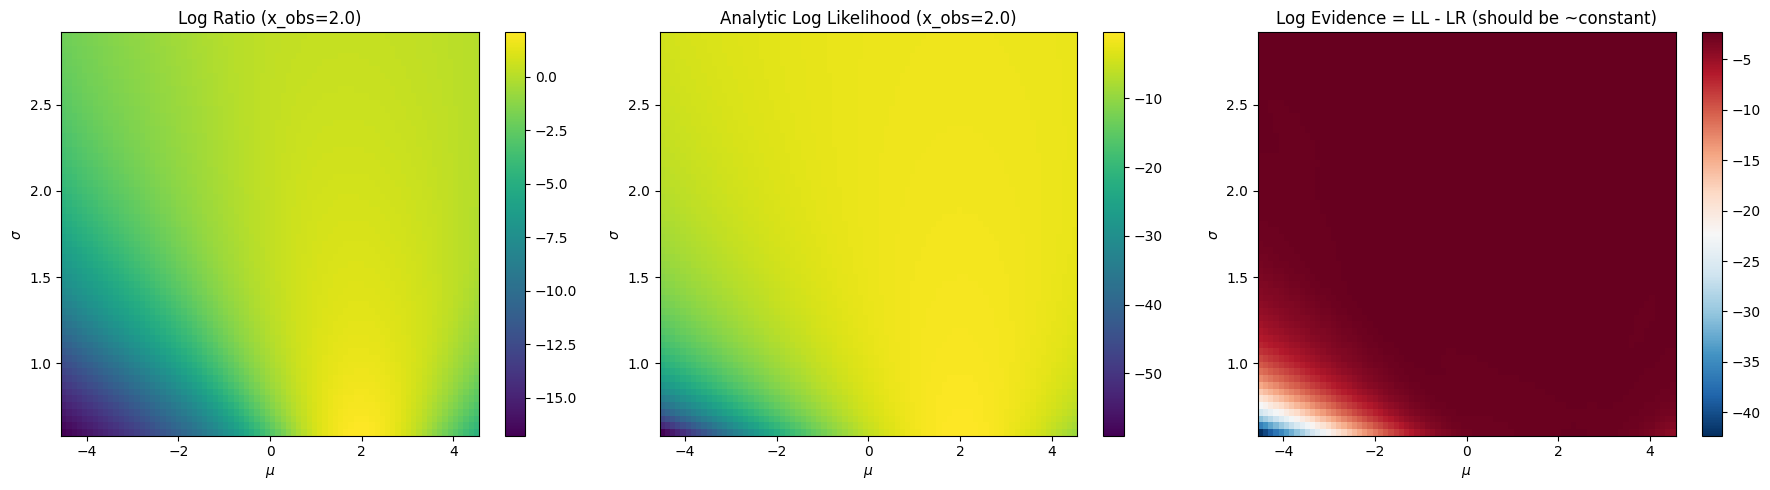

In [10]:
x_obs_val = 2.0
mu_grid = np.linspace(-4.5, 4.5, 80)
sigma_grid = np.linspace(0.6, 2.9, 60)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

# Flatten for vmap
mu_flat = jnp.array(MU.flatten())
sigma_flat = jnp.array(SIGMA.flatten())
x_flat = jnp.full_like(mu_flat, x_obs_val)

# Evaluate extracted log-ratio
vmap_fn_all = jax.vmap(single_trial_fn, in_axes=(0, 0, 0))
lr_flat = np.asarray(vmap_fn_all(x_flat, mu_flat, sigma_flat))
LR = lr_flat.reshape(MU.shape)

# Analytic log-likelihood
LL = sp_norm.logpdf(x_obs_val, loc=MU, scale=SIGMA)

# Log evidence = log_lik - log_ratio (should be ~constant where well-calibrated)
LE = LL - LR

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(MU, SIGMA, LR, shading='auto', cmap='viridis')
axes[0].set_title(f"Log Ratio (x_obs={x_obs_val})")
axes[0].set_xlabel("$\\mu$")
axes[0].set_ylabel("$\\sigma$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(MU, SIGMA, LL, shading='auto', cmap='viridis')
axes[1].set_title(f"Analytic Log Likelihood (x_obs={x_obs_val})")
axes[1].set_xlabel("$\\mu$")
axes[1].set_ylabel("$\\sigma$")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(MU, SIGMA, LE, shading='auto', cmap='RdBu_r')
axes[2].set_title(f"Log Evidence = LL - LR (should be ~constant)")
axes[2].set_xlabel("$\\mu$")
axes[2].set_ylabel("$\\sigma$")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

### Log-Ratio vs. $\mu$ for Fixed $\sigma$ Slices

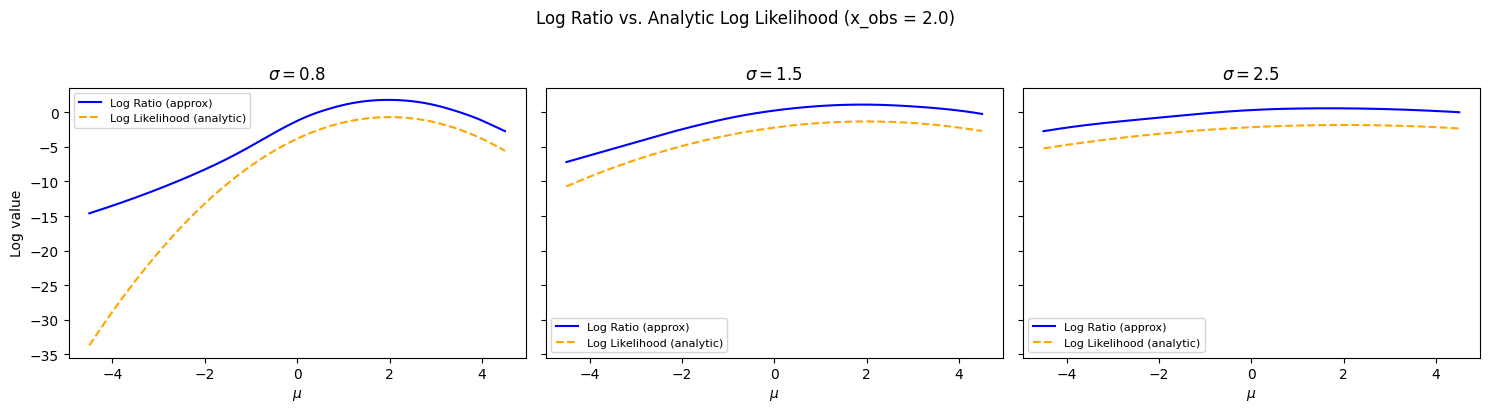

In [11]:
sigma_slices = [0.8, 1.5, 2.5]
mu_vals = np.linspace(-4.5, 4.5, 200)

fig, axes = plt.subplots(1, len(sigma_slices), figsize=(5 * len(sigma_slices), 4), sharey=True)

for i, sig_val in enumerate(sigma_slices):
    mu_j = jnp.array(mu_vals)
    sig_j = jnp.full_like(mu_j, sig_val)
    x_j = jnp.full_like(mu_j, x_obs_val)
    
    lr_vals = np.asarray(vmap_fn_all(x_j, mu_j, sig_j))
    ll_vals = sp_norm.logpdf(x_obs_val, loc=mu_vals, scale=sig_val)
    
    ax = axes[i]
    ax.plot(mu_vals, lr_vals, label="Log Ratio (approx)", color="blue")
    ax.plot(mu_vals, ll_vals, label="Log Likelihood (analytic)", color="orange", linestyle="--")
    ax.set_title(f"$\\sigma = {sig_val}$")
    ax.set_xlabel("$\\mu$")
    if i == 0:
        ax.set_ylabel("Log value")
    ax.legend(fontsize=8)

plt.suptitle(f"Log Ratio vs. Analytic Log Likelihood (x_obs = {x_obs_val})", y=1.02)
plt.tight_layout()
plt.show()

---
## Part 3: Wrap in PyTensor Op with Gradient Support (HSSM-style)

We now replicate the key utility functions from HSSM's `func_utils.py` and `jax.py` **inline**
in the notebook. This provides:
- `make_vjp_func`: creates a VJP closure using `jax.vjp`
- `make_vmap_func`: vectorizes via `jax.vmap`, returns `(jitted_logp, jitted_vjp, logp_nojit)` triple
- `make_jax_logp_ops`: creates `LANLogpOp` and `LANLogpVJPOp` PyTensor Ops

No HSSM import is needed -- everything is self-contained.

In [12]:
# ========================================================
# Replicated from HSSM's func_utils.py (self-contained)
# ========================================================

def make_vjp_func(logp, params_only=False):
    """Make a non-jitted VJP of the logp function."""
    def vjp_logp(*inputs, gz=None, params_only=False):
        _, vjp_fn = vjp(logp, *inputs)
        if params_only:
            return vjp_fn(gz)
        else:
            return vjp_fn(gz)[1:]  # skip data gradient
    vjp_logp = Partial(vjp_logp, params_only=params_only)
    return vjp_logp


def make_vmap_func(logp, in_axes, params_only=False):
    """Make a vectorized version of the logp function, its VJP, and the nojit version."""
    vmap_logp = vmap(logp, in_axes=in_axes)
    vjp_vmap_logp = make_vjp_func(vmap_logp, params_only=params_only)
    return jit(vmap_logp), jit(vjp_vmap_logp), vmap_logp


def make_jax_logp_funcs_from_callable(logp, params_is_reg, params_only=False):
    """Build vmap + VJP wrappers from a single-trial JAX callable."""
    in_axes = [0 if is_reg else None for is_reg in params_is_reg]
    if not params_only:
        in_axes.insert(0, 0)  # data axis is always vectorized
    return make_vmap_func(logp, in_axes=in_axes, params_only=params_only)

In [13]:
# ========================================================
# Replicated from HSSM's jax.py (self-contained)
# ========================================================

def make_jax_logp_ops(logp, logp_vjp, logp_nojit):
    """Wrap JAX functions and their gradient in PyTensor Ops.
    
    Returns a PyTensor Op whose `grad()` method invokes the VJP Op,
    and which dispatches to native JAX via `jax_funcify`.
    """
    class LANLogpOp(Op):
        def make_node(self, data, *dist_params):
            inputs = [pt.as_tensor_variable(p) for p in dist_params]
            self.has_data = data is not None
            if self.has_data:
                inputs = [pt.as_tensor_variable(data)] + inputs
            outputs = [pt.vector()]
            return Apply(self, inputs, outputs)

        def perform(self, node, inputs, output_storage):
            result = logp(*inputs)
            output_storage[0][0] = np.asarray(result, dtype=node.outputs[0].dtype)

        def grad(self, inputs, output_gradients):
            if self.has_data:
                results = lan_logp_vjp_op(
                    inputs[0], *inputs[1:], gz=output_gradients[0]
                )
            else:
                results = lan_logp_vjp_op(None, *inputs, gz=output_gradients[0])
            output = results
            if self.has_data:
                output = [
                    pytensor.gradient.grad_not_implemented(self, 0, inputs[0]),
                ] + output
            return output

    class LANLogpVJPOp(Op):
        def make_node(self, data, *dist_params, gz):
            self.has_data = data is not None
            inputs = [pt.as_tensor_variable(p) for p in dist_params]
            if self.has_data:
                inputs = [pt.as_tensor_variable(data)] + inputs
            inputs += [pt.as_tensor_variable(gz)]
            if self.has_data:
                outputs = [inp.type() for inp in inputs[1:-1]]
            else:
                outputs = [inp.type() for inp in inputs[:-1]]
            return Apply(self, inputs, outputs)

        def perform(self, node, inputs, outputs):
            if self.has_data:
                results = logp_vjp(*inputs[:-1], gz=inputs[-1])
            else:
                results = logp_vjp(*inputs[:-1], gz=inputs[-1])
            for i, result in enumerate(results):
                outputs[i][0] = np.asarray(result, dtype=node.outputs[i].dtype)

    lan_logp_op = LANLogpOp()
    lan_logp_vjp_op = LANLogpVJPOp()

    @jax_funcify.register(LANLogpOp)
    def logp_op_dispatch(op, **kwargs):
        return logp_nojit

    return lan_logp_op

### Wire Everything Together

For the scalar-parameter NUTS example (Part 5), **both** mu and sigma are the same for all trials.
But since we need to vmap over data, at least data must be vectorized.
We set `params_is_reg=[True, True]` so that both parameters are expected as vectors
(we'll broadcast scalars to vectors in the PyMC model).

In [14]:
# Build the Ops for the case where both params are trial-wise vectors
logp_jit, logp_vjp_jit, logp_nojit = make_jax_logp_funcs_from_callable(
    single_trial_fn,
    params_is_reg=[True, True],  # both params will be vectors
)

ratio_op = make_jax_logp_ops(logp_jit, logp_vjp_jit, logp_nojit)
print("Op created:", ratio_op)

Op created: LANLogpOp


---
## Part 4: Build a Proper `pm.Distribution`

This is a **real PyMC distribution** with:
- A `logp()` method that accepts observed data + distribution parameters
- Parameters that can be scalars or per-trial vectors
- Gradient support enabling NUTS

Unlike the `pm.Potential` approach in the original notebook, this makes the trained
ratio estimator a first-class citizen of the PyMC modeling ecosystem.

In [15]:
from pytensor.tensor.random.op import RandomVariable

def make_ratio_distribution(ratio_op, list_params, simulator_fn=None):
    """Factory that creates a pm.Distribution class using the given ratio Op.
    
    Parameters
    ----------
    ratio_op : PyTensor Op
        The Op wrapping the vmapped + VJP log-ratio function.
    list_params : list of str
        Parameter names, in the order the Op expects them.
    simulator_fn : callable, optional
        A function (rng, *params, size) -> np.ndarray for prior/posterior predictive.
        If None, sampling from the RV will raise NotImplementedError.
    """
    # Build a minimal RandomVariable for the rv_op slot
    sig = ",".join(["()" for _ in list_params]) + "->()"
    
    class SimpleRV(RandomVariable):
        name = "ratio_rv"
        signature = sig
        dtype = "floatX"
        _print_name = ("RatioRV", "\\operatorname{RatioRV}")
    
        @classmethod
        def rng_fn(cls, rng, *args, **kwargs):
            if simulator_fn is not None:
                return simulator_fn(rng, *args, **kwargs)
            raise NotImplementedError("Sampling not implemented for this distribution.")
    
    class RatioDistribution(pm.Distribution):
        rv_op = SimpleRV()
        _params = list_params
    
        @classmethod
        def dist(cls, **kwargs):
            dist_params = [
                pt.as_tensor_variable(pm.floatX(kwargs[p])) for p in cls._params
            ]
            other_kwargs = {k: v for k, v in kwargs.items() if k not in cls._params}
            return super().dist(dist_params, **other_kwargs)
    
        def logp(data, *dist_params):
            # Broadcast scalar params to match data shape
            n_obs = data.shape[0]
            dist_params = tuple(
                pt.broadcast_to(p, (n_obs,)) for p in dist_params
            )
            return ratio_op(data, *dist_params)
    
    return RatioDistribution


RatioDistribution = make_ratio_distribution(
    ratio_op,
    list_params=["mu", "sigma"],
)

print("Distribution class created:", RatioDistribution)

Distribution class created: <class '__main__.make_ratio_distribution.<locals>.RatioDistribution'>


---
## Part 5: PyMC Model with NUTS (Scalar Parameters)

Both $\mu$ and $\sigma$ are scalar (same value for all trials). We simulate observed data
from the true model and recover the parameters using NUTS.

In [16]:
# Ground truth parameters
mu_true = 2.0
sigma_true = 1.5
n_obs = 50

# Simulate observed data
np.random.seed(42)
x_observed = np.random.normal(loc=mu_true, scale=sigma_true, size=n_obs).astype(np.float32)

print(f"Observed data: n={n_obs}, mean={x_observed.mean():.3f}, std={x_observed.std():.3f}")
print(f"True: mu={mu_true}, sigma={sigma_true}")

Observed data: n=50, mean=1.662, std=1.386
True: mu=2.0, sigma=1.5


In [17]:
with pm.Model() as scalar_model:
    # --- Truncated priors that respect the training data regime ---
    # The ratio estimator was trained with mu ~ U(-5,5), sigma ~ U(0.5, 3.0).
    # Using truncated priors keeps the sampler inside the region where the
    # network provides meaningful gradients.
    mu = pm.TruncatedNormal("mu", mu=0, sigma=5, lower=-5, upper=5)
    sigma = pm.TruncatedNormal(
        "sigma", mu=1.5, sigma=1.5, lower=0.5, upper=3.0
    )

    obs = RatioDistribution("obs", mu=mu, sigma=sigma, observed=x_observed)

    # --- Controlled starting points ---
    # Start all chains near the centre of the training regime to avoid
    # the sampler initialising in a region where the network is unreliable.
    trace = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=4,
        tune=1000,
        random_seed=42,
        initvals={"mu": 0.0, "sigma": 1.5},
    )


/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:03<00:00, 552.87it/s, 3 steps of size 7.74e-01. acc. prob=0.93]


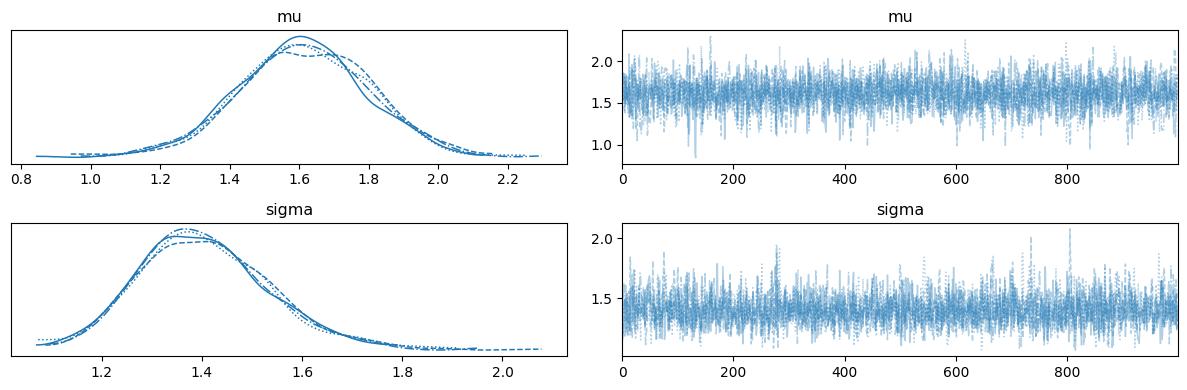

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     1.613  0.189   1.267    1.978      0.003    0.003    3032.0    2365.0   
sigma  1.406  0.132   1.153    1.648      0.002    0.002    2942.0    2445.0   

       r_hat  
mu       1.0  
sigma    1.0  

True values: mu=2.0, sigma=1.5


In [18]:
import arviz as az

az.plot_trace(trace, var_names=["mu", "sigma"])
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["mu", "sigma"]))
print(f"\nTrue values: mu={mu_true}, sigma={sigma_true}")

### Compare to Analytic Posterior

For the normal-normal conjugate model with known $\sigma$, the analytic posterior for $\mu$ is:
$$\mu \mid x_{1:n} \sim \mathcal{N}\left(\bar{x}, \frac{\sigma^2}{n}\right)$$

Since we're estimating $\sigma$ too, we compare the marginal posteriors visually.

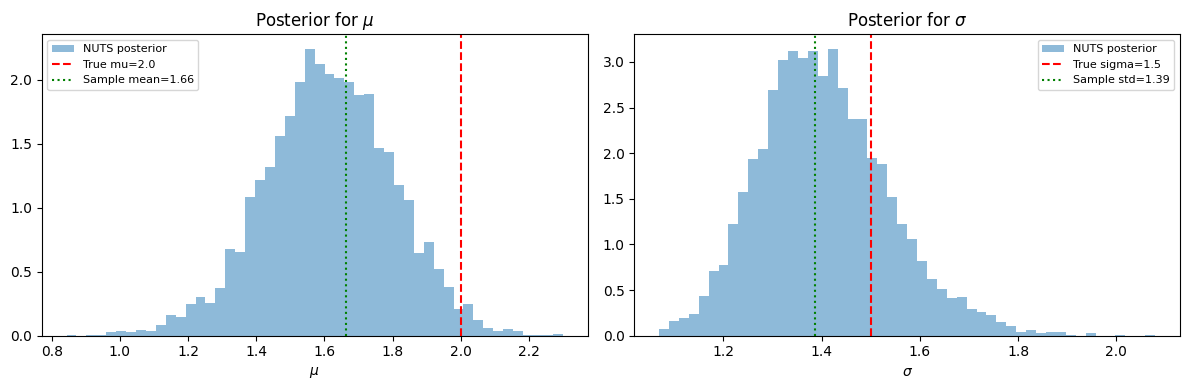

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Posterior for mu
mu_samples = trace.posterior["mu"].values.flatten()
axes[0].hist(mu_samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
axes[0].axvline(mu_true, color='r', linestyle='--', label=f'True mu={mu_true}')
axes[0].axvline(x_observed.mean(), color='g', linestyle=':', label=f'Sample mean={x_observed.mean():.2f}')
axes[0].set_xlabel("$\\mu$")
axes[0].set_title("Posterior for $\\mu$")
axes[0].legend(fontsize=8)

# Posterior for sigma
sigma_samples = trace.posterior["sigma"].values.flatten()
axes[1].hist(sigma_samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
axes[1].axvline(sigma_true, color='r', linestyle='--', label=f'True sigma={sigma_true}')
axes[1].axvline(x_observed.std(), color='g', linestyle=':', label=f'Sample std={x_observed.std():.2f}')
axes[1].set_xlabel("$\\sigma$")
axes[1].set_title("Posterior for $\\sigma$")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Part 6: Regression Example -- Per-Trial $\mu$ via Covariates

This is the key demonstration of HSSM-like flexibility: $\mu$ varies across trials as a
function of a covariate, while $\sigma$ remains a scalar.

### The `in_axes` Mechanism

When we set `params_is_reg=[True, False]`, the vmap wrapping uses:
```
in_axes = [0, 0, None]  # (data, mu, sigma)
```
This means:
- **data** (`x_i`): vectorized over axis 0 (one per trial)
- **mu**: vectorized over axis 0 (one per trial -- regression output)
- **sigma**: NOT vectorized (same scalar for all trials)

This is exactly how HSSM handles trial-wise regression parameters vs. shared parameters.
We need a **different Op instance** for this parameter configuration.

In [20]:
# Build a new Op with mixed vectorization: mu is per-trial, sigma is scalar
logp_jit_reg, logp_vjp_jit_reg, logp_nojit_reg = make_jax_logp_funcs_from_callable(
    single_trial_fn,
    params_is_reg=[True, False],  # mu is per-trial, sigma is scalar
)

ratio_op_reg = make_jax_logp_ops(logp_jit_reg, logp_vjp_jit_reg, logp_nojit_reg)
print("Regression Op created:", ratio_op_reg)

Regression Op created: LANLogpOp


In [21]:
# Build distribution for the regression case
# In this case, mu is already a vector from the regression, so we only broadcast sigma

def make_ratio_distribution_reg(ratio_op_reg, list_params, params_is_reg):
    """Factory for regression case where some params are per-trial vectors."""
    sig = ",".join(["()" for _ in list_params]) + "->()"
    
    class SimpleRV(RandomVariable):
        name = "ratio_rv_reg"
        signature = sig
        dtype = "floatX"
        _print_name = ("RatioRVReg", "\\operatorname{RatioRVReg}")
    
        @classmethod
        def rng_fn(cls, rng, *args, **kwargs):
            raise NotImplementedError("Sampling not implemented.")
    
    class RatioDistributionReg(pm.Distribution):
        rv_op = SimpleRV()
        _params = list_params
        _params_is_reg = params_is_reg
    
        @classmethod
        def dist(cls, **kwargs):
            dist_params = [
                pt.as_tensor_variable(pm.floatX(kwargs[p])) for p in cls._params
            ]
            other_kwargs = {k: v for k, v in kwargs.items() if k not in cls._params}
            return super().dist(dist_params, **other_kwargs)
    
        def logp(data, *dist_params):
            n_obs = data.shape[0]
            # Only broadcast trial-wise params; leave scalar params as-is
            dist_params_processed = []
            for i, (p, is_reg) in enumerate(zip(dist_params, RatioDistributionReg._params_is_reg)):
                if is_reg:
                    dist_params_processed.append(pt.broadcast_to(p, (n_obs,)))
                else:
                    # Scalar parameter: do NOT broadcast
                    dist_params_processed.append(pt.squeeze(p))
            return ratio_op_reg(data, *dist_params_processed)
    
    return RatioDistributionReg

RatioDistributionReg = make_ratio_distribution_reg(
    ratio_op_reg,
    list_params=["mu", "sigma"],
    params_is_reg=[True, False],
)
print("Regression Distribution class created:", RatioDistributionReg)

Regression Distribution class created: <class '__main__.make_ratio_distribution_reg.<locals>.RatioDistributionReg'>


### Generate Regression Data

We simulate data where $\mu_i = \beta_0 + \beta_1 \cdot \text{condition}_i$
and $\sigma$ is constant across trials.

In [22]:
# True regression parameters
beta_0_true = 1.0
beta_1_true = 2.0
sigma_reg_true = 1.0
n_obs_reg = 100

np.random.seed(123)

# Binary condition: 0 or 1
condition_data = np.random.choice([0, 1], size=n_obs_reg).astype(np.float32)

# Per-trial mu
mu_per_trial = beta_0_true + beta_1_true * condition_data

# Simulate observations
x_reg_observed = np.random.normal(loc=mu_per_trial, scale=sigma_reg_true).astype(np.float32)

print(f"n_obs: {n_obs_reg}")
print(f"Condition counts: 0->{(condition_data==0).sum()}, 1->{(condition_data==1).sum()}")
print(f"True: beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

n_obs: 100
Condition counts: 0->55, 1->45
True: beta_0=1.0, beta_1=2.0, sigma=1.0


### Build PyMC Regression Model

In [23]:
with pm.Model() as regression_model:
    # --- Truncated priors that respect the training data regime ---
    # mu_i = beta_0 + beta_1 * condition_i, and condition in {0,1}.
    # We need mu_i in [-5, 5] for every trial, so we constrain the betas
    # conservatively to keep their sum inside the training range.
    beta_0 = pm.TruncatedNormal("beta_0", mu=0, sigma=3, lower=-4, upper=4)
    beta_1 = pm.TruncatedNormal("beta_1", mu=0, sigma=3, lower=-4, upper=4)
    sigma = pm.TruncatedNormal(
        "sigma", mu=1.5, sigma=1.5, lower=0.5, upper=3.0
    )

    # mu is now a per-trial vector
    mu_reg = beta_0 + beta_1 * condition_data  # shape (n_obs_reg,)

    obs = RatioDistributionReg("obs", mu=mu_reg, sigma=sigma, observed=x_reg_observed)

    # --- Controlled starting points ---
    trace_reg = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=4,
        tune=1000,
        random_seed=42,
        initvals={"beta_0": 0.0, "beta_1": 0.0, "sigma": 1.5},
    )


/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:05<00:00, 352.39it/s, 7 steps of size 5.94e-01. acc. prob=0.92] 


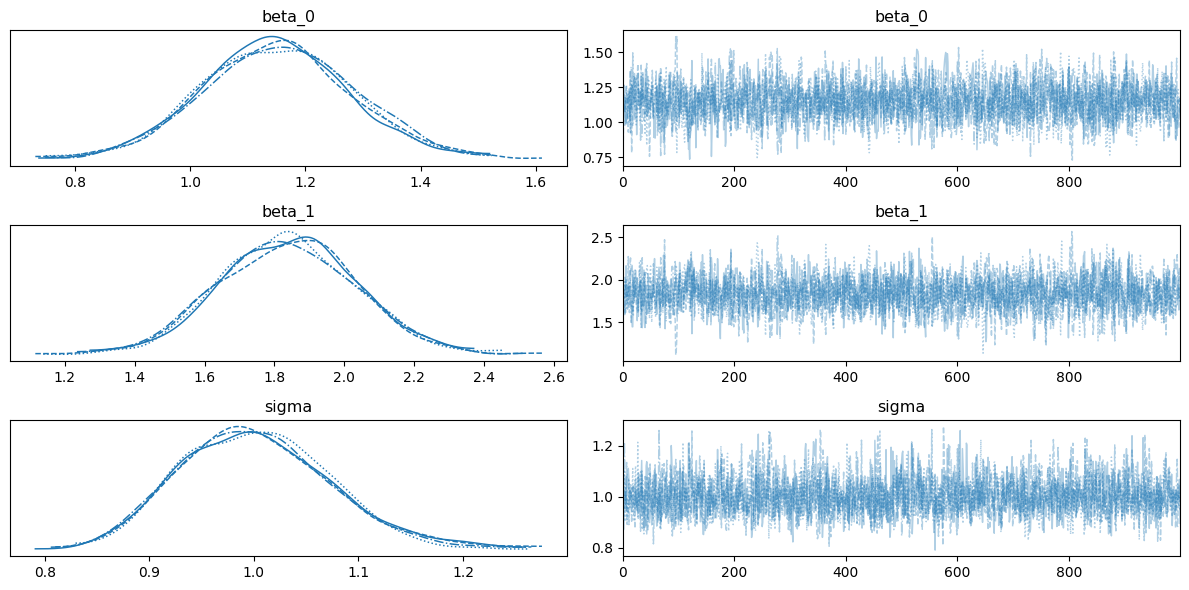

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta_0  1.150  0.131   0.891    1.387      0.003    0.002    2202.0    2065.0   
beta_1  1.837  0.197   1.485    2.216      0.004    0.003    2163.0    2503.0   
sigma   1.003  0.073   0.877    1.148      0.001    0.001    2404.0    2421.0   

        r_hat  
beta_0    1.0  
beta_1    1.0  
sigma     1.0  

True values: beta_0=1.0, beta_1=2.0, sigma=1.0


In [24]:
az.plot_trace(trace_reg, var_names=["beta_0", "beta_1", "sigma"])
plt.tight_layout()
plt.show()

print(az.summary(trace_reg, var_names=["beta_0", "beta_1", "sigma"]))
print(f"\nTrue values: beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

In [25]:
# Compare to simple OLS estimates
from numpy.linalg import lstsq

X_design = np.column_stack([np.ones(n_obs_reg), condition_data])
ols_coeffs, _, _, _ = lstsq(X_design, x_reg_observed, rcond=None)
ols_residuals = x_reg_observed - X_design @ ols_coeffs
ols_sigma = np.std(ols_residuals, ddof=2)

print(f"OLS estimates: beta_0={ols_coeffs[0]:.3f}, beta_1={ols_coeffs[1]:.3f}, sigma={ols_sigma:.3f}")
print(f"True values:   beta_0={beta_0_true}, beta_1={beta_1_true}, sigma={sigma_reg_true}")

OLS estimates: beta_0=1.181, beta_1=1.850, sigma=1.070
True values:   beta_0=1.0, beta_1=2.0, sigma=1.0


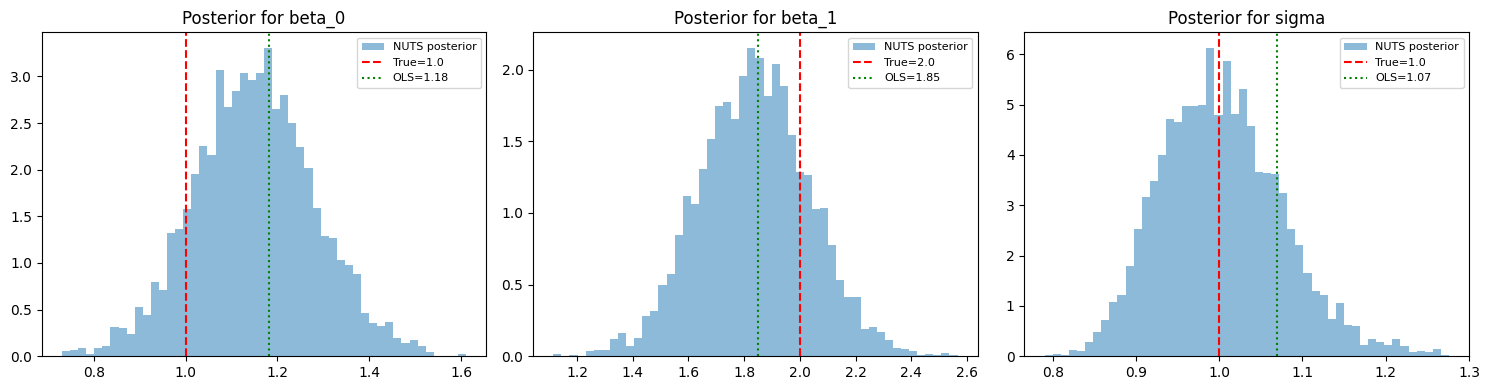

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, true_val) in enumerate([
    ("beta_0", beta_0_true),
    ("beta_1", beta_1_true),
    ("sigma", sigma_reg_true),
]):
    samples = trace_reg.posterior[name].values.flatten()
    axes[i].hist(samples, bins=50, density=True, alpha=0.5, label="NUTS posterior")
    axes[i].axvline(true_val, color='r', linestyle='--', label=f'True={true_val}')
    if name != "sigma":
        axes[i].axvline(ols_coeffs[i], color='g', linestyle=':', label=f'OLS={ols_coeffs[i]:.2f}')
    else:
        axes[i].axvline(ols_sigma, color='g', linestyle=':', label=f'OLS={ols_sigma:.2f}')
    axes[i].set_title(f"Posterior for {name}")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Discussion

This notebook demonstrates the complete bridge from a trained BayesFlow `RatioApproximator`
to a fully functional PyMC distribution with gradient support. The key ideas are:

1. **JAX extraction**: Since BayesFlow uses Keras 3 with the JAX backend, we can extract
   a pure JAX callable by directly calling the classifier network, bypassing the dict-based adapter.

2. **HSSM-style PyTensor wrapping**: The `LANLogpOp` + `LANLogpVJPOp` pattern provides:
   - A forward pass Op with a `grad()` method that invokes the VJP Op
   - Native JAX dispatch via `jax_funcify.register`
   - Full gradient support enabling NUTS/HMC sampling

3. **`params_is_reg` controls vectorization**: The `in_axes` mechanism determines which
   parameters are vmapped (per-trial vectors) and which are broadcast (scalars).
   Different parameter configurations require different Op instances.

4. **Proper `pm.Distribution`**: Unlike `pm.Potential`, this approach creates a real
   distribution with a `logp()` method and observed data as a PyMC variable.

### Connection to HSSM and Bambi

This pattern generalizes: **any parameter can be made trial-wise** by expressing it as a
function of covariates, and the vmap machinery handles the rest. This is the exact bridge
to HSSM/Bambi:

- **Bambi** would automate the formula parsing (e.g., `"mu ~ 1 + condition"`) and
  `params_is_reg` configuration
- **HSSM** provides the SSM-specific simulator for `rng_fn` and manages parameter bounds

The underlying mechanism is what we built in this notebook.